In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv('Social_Network_Ads.csv')

In [3]:
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
209,15697424,Female,46,22000,0
1,15810944,Male,35,20000,0
91,15636428,Female,30,116000,0
311,15622585,Male,39,96000,1
282,15750447,Male,37,70000,1


In [7]:
df=df.iloc[:,2:]

In [8]:
df.sample(5)

,Age,EstimatedSalary,Purchased
117,36,52000,0
311,39,96000,1
3,27,57000,0
332,42,65000,0
11,26,52000,0


## Train Test Split

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop('Purchased',axis=1),
                                              df['Purchased'],
                                              test_size=0.3, 
                                              random_state=42, 
                                              )
X_train.shape,X_test.shape

((280, 2), (120, 2))

## StandardScaler

In [17]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler() 
#fit the scaler to the train set,it will learn the parameters
scaler.fit(X_train)
# transform train and test sets 
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [18]:
scaler.mean_

array([3.75750000e+01, 7.05892857e+04])

In [29]:
# X_train
# X_train_scaled

In [21]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [22]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.6,70589.3
std,10.2,33948.5
min,18.0,15000.0
25%,30.0,44000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [24]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.7,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


## Effect of Scaling

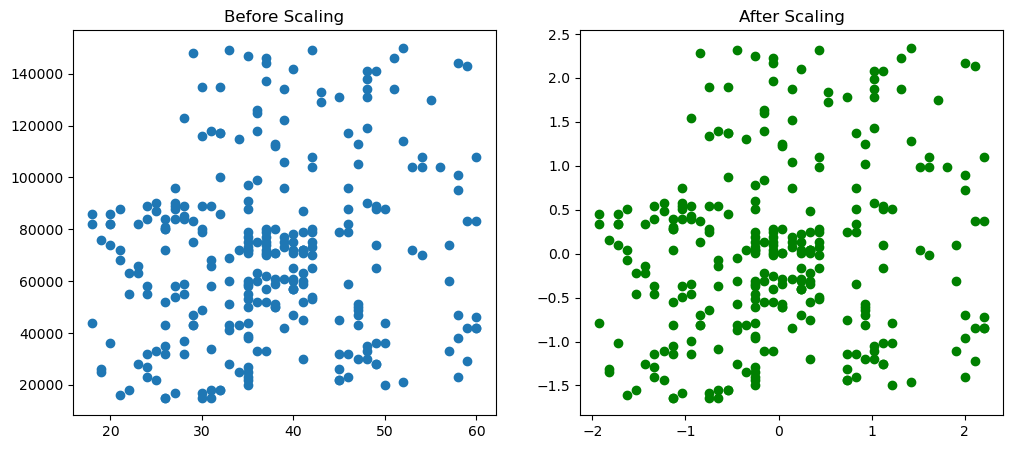

In [30]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],color='green')
ax2.set_title('After Scaling')
plt.show()

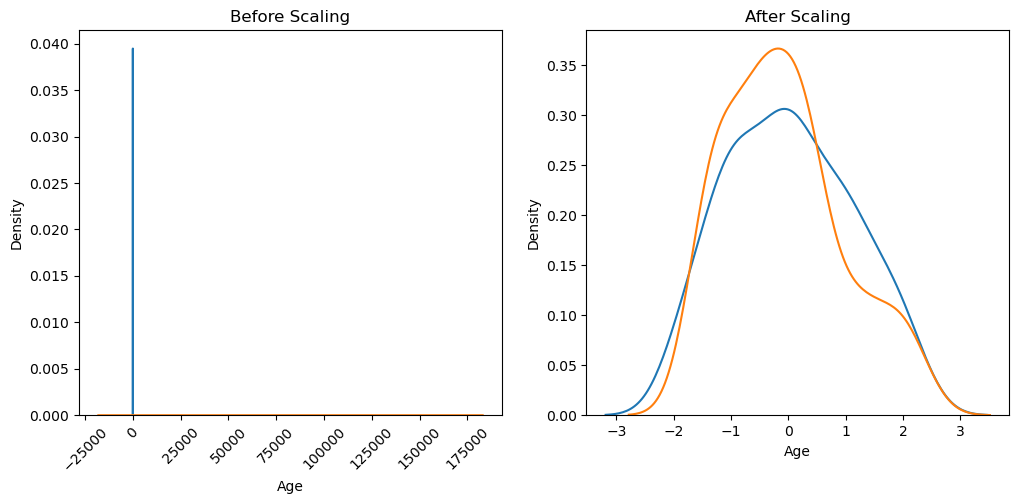

In [37]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
# Before Scaling 
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)
ax1.tick_params(axis='x',rotation=45)
# plt.xlabel(rotate=45)

# After Scaling 
ax2.set_title('After Scaling')
sns.kdeplot(X_test_scaled['Age'],ax=ax2)
sns.kdeplot(X_test_scaled['EstimatedSalary'],ax=ax2)
plt.show()

## Comparison of Distributions

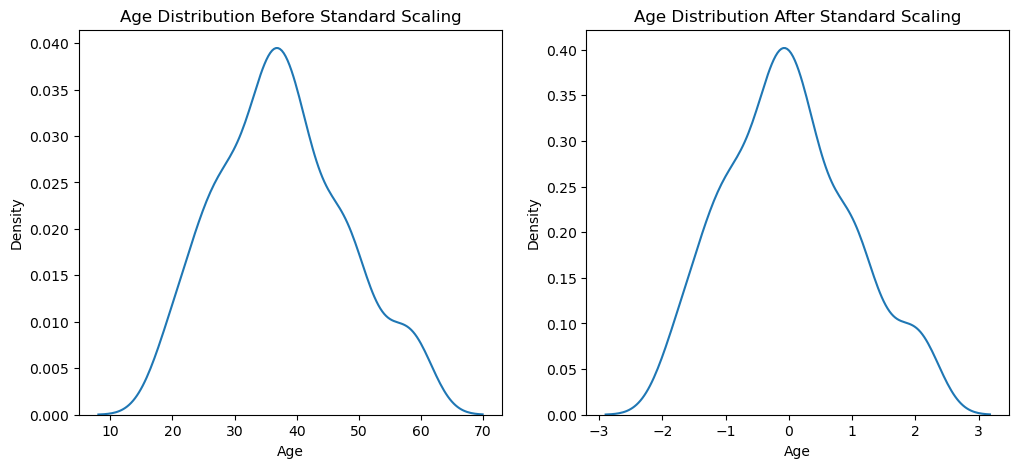

In [40]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
# Before Scaling 
ax1.set_title('Age Distribution Before Standard Scaling')
sns.kdeplot(X_train['Age'],ax=ax1)
# After Scaling 
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
plt.show()

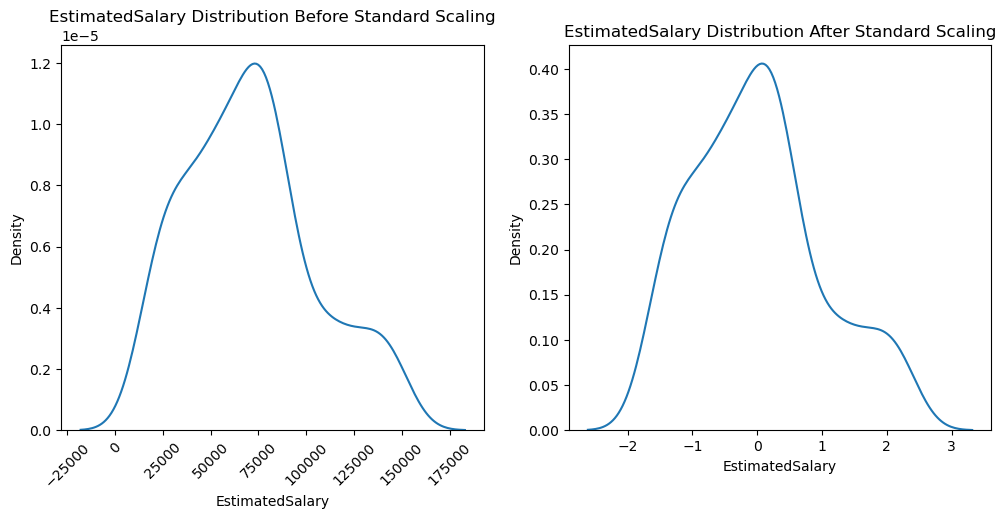

In [42]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
# Before Scaling 
ax1.set_title('EstimatedSalary Distribution Before Standard Scaling')
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)
ax1.tick_params(axis='x',rotation=45)
# After Scaling 
ax2.set_title('EstimatedSalary Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)
plt.show()